# 5c — Monthly S2D Spatial Analysis
## JRA55\_FOSIRL vs Reanalysis: Bias and Drift Adjustment

This notebook orchestrates the `workflows/diagnostics/monthly_drift/` workflow and provides
interactive exploration of spatial bias and drift diagnostics.

### Relationship to other workflows

| Notebook | Scope |
|---|---|
| 5a\_refactor\_drift\_analysis | Regional (scalar) drift for Niño3.4 etc. |
| 5b\_refactor\_ic\_analysis | IC restart file audit |
| **5c (this notebook)** | Full spatial monthly bias and drift |

### Recommended progression

1. Run pilot (1980–1982, May and November, PRECT) through Steps 1–9.
2. Confirm inventory gate passes (all pilot rows ANALYSIS\_READY).
3. Verify D(τ₀) = 0 exactly at every grid point (lead-1 adjustment).
4. Check PRECT bias maps for physical plausibility (mm/day scale).
5. Confirm May and November bootstraps produce separate outputs.
6. Scale to full 1980–1986 campaign with `PILOT_ONLY = False`.
7. Extend to TREFHT, LHFLX, SHFLX.

> ℹ️ **Gate logic** — missing lead 20 blocks `second_year` (13–24) but does NOT block `months_1_3`, `months_4_6`, or `months_10_12`.


In [14]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import sys
import esp_lab

# Development-checkout fallback: a clean install exposes ``workflows`` directly.
REPO_ROOT = Path(esp_lab.__file__).resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from workflows.diagnostics.monthly_drift import bootstrap as bootstrap_workflow
from workflows.diagnostics.monthly_drift import config as configuration
from workflows.diagnostics.monthly_drift import diagnostics as diagnostics_workflow
from workflows.diagnostics.monthly_drift import inventory as inventory_workflow
from workflows.diagnostics.monthly_drift import plotting as plotting_workflow
from workflows.diagnostics.monthly_drift import preprocess as preprocessing_workflow

from esp_lab.diagnostics.monthly_core import (
    MonthlyConfig, GateStatus, InventoryStatus,
    check_lead_coverage, classify_analysis_status,
    bootstrap_spatial_ci, significance_mask,
    window_average,
)
from esp_lab.utils.dask_utils import DaskConfig, get_cluster_client, close_cluster

MONTHLY_DIR = Path(configuration.__file__).resolve().parent
print('Monthly S2D imports OK')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Monthly S2D imports OK


## Dask Setup

In [15]:
from esp_lab.diagnostics.store import (
    diagnostic_store_is_valid, diagnostic_store_path,
    dataframe_fingerprint, file_fingerprint, load_diagnostic_store, save_diagnostic_store,
)

machine_env = os.environ.get('CLUSTER_TYPE', 'local')

dask_cfg = DaskConfig(
    cluster_type=machine_env,
    workers=8,
    cores=4,
    memory='16GB',
    walltime='04:00:00',
)

cluster, client = get_cluster_client(dask_cfg)
print(client)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38939 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:33513' processes=4 threads=4, memory=14.90 GiB>


2026-08-09 14:42:07,401 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('mean_chunk-f7ebbcad37cae145760cd2dd42ed73d8', 2, 0, 0, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('mean_chunk-f7ebbcad37cae145760cd2dd42ed73d8', 2, 0, 0, 0, 0)->('concatenate-getitem-mul-rechunk-merge-rechunk-split-mean_chunk-f7ebbcad37cae145760cd2dd42ed73d8', 2, 0, 0, 0, 0))
new run_spec: Alias(('mean_chunk-f7ebbcad37cae145760cd2dd42ed73d8', 2, 0, 0, 0, 0)->('concatenate-getitem-mul-open_dataset-PRECT-original-rechunk-merge-rechunk-split-mean_chunk-f7ebbcad37cae145760cd2dd-1bdc', 2, 0, 0, 0, 0))
old depende

## User Configuration

**All** parameters are defined here.  No other cell below needs changing.


In [16]:
# ── Machine/user-specific output locations ────────────────────
# Edit these defaults here, or set the corresponding environment variables
# before starting Jupyter. Only this configuration cell needs changing.
S2D_DIAG_ROOT = Path(os.environ.get(
    'ESP_LAB_S2D_DIAG_ROOT',
    '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag',
))
FIGURE_ROOT = Path(os.environ.get(
    'ESP_LAB_FIGURE_OUTDIR',
    '/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag',
))
DIAGNOSTIC_OUTDIR = S2D_DIAG_ROOT / 'multimodel' / 'leadtime_drift' / 'atm' / 'monthly_spatial'
FIGURE_OUTDIR = FIGURE_ROOT / 'leadtime_drift' / 'atm' / 'monthly_spatial'
DIAGNOSTIC_OUTDIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

# ── Pilot toggle ────────────────────────────────────────────────
# Set PILOT_ONLY = False to run the full 1980-1986, May+November campaign.
PILOT_ONLY    = True
PILOT_YEARS   = [1980, 1981, 1982]
PILOT_MONTHS  = [5, 11]       # Both columns in the paired-difference grid
VARIABLE      = 'PRECT'       # Start with PRECT; extend to TREFHT etc.
GATE_STRICT   = False         # True = SystemExit(1) on gate failure
OBS_PATH      = None          # Set to '/path/to/GPCP.nc' when obs available
N_BOOTSTRAP   = 1000
OUTPUT_ROOT   = str(DIAGNOSTIC_OUTDIR)
REUSE_DIAGNOSTICS = True    # False forces raw-data recomputation

# ── Build MonthlyConfig ──────────────────────────────────────────
config = configuration.build_monthly_config(
    pilot_only=PILOT_ONLY,
    pilot_years=PILOT_YEARS,
    pilot_months=PILOT_MONTHS,
    variable_filter=[VARIABLE],
    gate_strict=GATE_STRICT,
    n_bootstrap=N_BOOTSTRAP,
    output_root=OUTPUT_ROOT,
)

STORE_CONTEXT = {'observations': file_fingerprint(OBS_PATH)}
STORE_PATH = diagnostic_store_path(OUTPUT_ROOT, 'monthly_drift', config, VARIABLE, context=STORE_CONTEXT)
STORE_VALID = REUSE_DIAGNOSTICS and diagnostic_store_is_valid(STORE_PATH, config, variable=VARIABLE, context=STORE_CONTEXT)
print('Diagnostic store:', STORE_PATH, '(reusable)' if STORE_VALID else '(will compute)')

print('Active years  :', config.active_years)
print('Active months :', config.active_months)
print('Members       :', config.members)
print('Leads         :', f'1-{max(config.leads)}')
print('Window defs   :', list(config.window_defs))
print('Data dir      :', config.data_dir)
print('Diagnostic dir:', DIAGNOSTIC_OUTDIR)
print('Figure dir    :', FIGURE_OUTDIR)


Diagnostic store: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/atm/monthly_spatial/diagnostics/monthly_drift/PRECT/5d565c2320806e39 (will compute)
Active years  : [1980, 1981, 1982]
Active months : [5, 11]
Members       : ['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09']
Leads         : 1-24
Window defs   : ['months_1_3', 'months_4_6', 'months_10_12', 'second_year']
Data dir      : /global/cfs/cdirs/e3sm/S2S2D/post_process
Diagnostic dir: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/atm/monthly_spatial
Figure dir    : /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial


## Steps 1–4 — File Discovery, Inventory and Paired Readiness Gate

Discovers all expected files, classifies each by analysis/archive status
(window-aware), and verifies that both experiments have paired complete data.

**Key output files:**
- `${ESP_LAB_S2D_DIAG_ROOT}/multimodel/leadtime_drift/atm/monthly_spatial/monthly_inventory.csv`
- `${ESP_LAB_S2D_DIAG_ROOT}/multimodel/leadtime_drift/atm/monthly_spatial/monthly_missing_data_report.txt`
- `${ESP_LAB_S2D_DIAG_ROOT}/multimodel/leadtime_drift/atm/monthly_spatial/monthly_inventory_summary.json`


In [17]:
%%time
inventory_df, report = inventory_workflow.run(
    pilot_only=PILOT_ONLY,
    variable=VARIABLE,
    season=None,   # None = use config.active_months
    skip_discovery=False,
    verbose=True,
    output_root=OUTPUT_ROOT,
    config=config,
)
STORE_CONTEXT['inventory'] = dataframe_fingerprint(inventory_df)
STORE_PATH = diagnostic_store_path(OUTPUT_ROOT, 'monthly_drift', config, VARIABLE, context=STORE_CONTEXT)
STORE_VALID = REUSE_DIAGNOSTICS and diagnostic_store_is_valid(STORE_PATH, config, variable=VARIABLE, context=STORE_CONTEXT)
print('Post-inventory diagnostic store:', STORE_PATH, '(reusable)' if STORE_VALID else '(will compute)')
display(inventory_df.groupby(['experiment', 'analysis_status'])
        .size().unstack(fill_value=0))


Monthly S2D — Steps 2–4: Inventory & Paired Readiness Gate
Monthly S2D — Step 1: File Discovery
  Experiments : ['JRA55_FOSIRL', 'Reanalysis']
  Init years  : [1980, 1981, 1982]
  Init months : [5, 11]
  Members     : 10 (EN00–EN09)
  Variables   : ['PRECT']
  Data dir    : /global/cfs/cdirs/e3sm/S2S2D/post_process



/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:238: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(


  [✓] JRA55_FOSIRL    1980050100 EN00 PRECT


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:238: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:238: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(


  [✓] JRA55_FOSIRL    1980050100 EN01 PRECT
  [✓] JRA55_FOSIRL    1980050100 EN02 PRECT


...

  [✓] Reanalysis      1982110100 EN08 PRECT


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:238: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(


  [✓] Reanalysis      1982110100 EN09 PRECT

  Raw inventory → /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/atm/monthly_spatial/monthly_inventory_raw.csv  (120 rows)

=== Paired Readiness Report ===
  Requested (init_tag, member): 60
  Common paired complete:        60
  Ref-only:                      0
  Test-only:                     0
  Gate pass: True

  Window blocking:
    months_1_3: 0 blocked
    months_4_6: 0 blocked
    months_10_12: 0 blocked
    second_year: 0 blocked

Analysis status breakdown:
analysis_status  ANALYSIS_READY
experiment                     
JRA55_FOSIRL                 60
Reanalysis                   60

Archive status breakdown:
archive_status  ARCHIVE_COMPLETE
experiment                      
JRA55_FOSIRL                  60
Reanalysis                    60

  Inventory    → /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/atm/monthly_spatial/monthly_inventory.csv
  Missing rpt  → /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/mu

analysis_status,ANALYSIS_READY
experiment,
JRA55_FOSIRL,60
Reanalysis,60


CPU times: user 3.06 s, sys: 1.23 s, total: 4.29 s
Wall time: 28.1 s


### Inspect paired readiness report

In [18]:
print(report.format_report())

# Show any blocked rows
blocked = inventory_df[inventory_df['analysis_status'] == 'BLOCKED']
if not blocked.empty:
    print(f'\n{len(blocked)} BLOCKED rows:')
    display(blocked[['experiment','init_tag','member','missing_leads','notes']]
            .head(20))
else:
    print('No BLOCKED rows — gate passes cleanly.')


=== Paired Readiness Report ===
  Requested (init_tag, member): 60
  Common paired complete:        60
  Ref-only:                      0
  Test-only:                     0
  Gate pass: True

  Window blocking:
    months_1_3: 0 blocked
    months_4_6: 0 blocked
    months_10_12: 0 blocked
    second_year: 0 blocked
No BLOCKED rows — gate passes cleanly.


## Step 5 — Preprocess

Loads the approved paired cohort, applies unit conversions (PRECT → mm/day),
optional masking, and returns `(Y, M, L, lat, lon)` DataArrays.


In [19]:
%%time
if STORE_VALID:
    results, boot_results = load_diagnostic_store(STORE_PATH)
    data, obs_da = {}, None
    print(f'Reused saved diagnostics: {STORE_PATH}')
else:
    data, obs_da = preprocessing_workflow.run_preprocess(
        config=config, inventory_df=inventory_df, report=report,
        field=VARIABLE, obs_path=OBS_PATH, verbose=True,
    )

# Quick shape check
for exp, months in data.items():
    for m, da in months.items():
        season_name = {5: 'May', 11: 'November'}.get(m, f'M{m:02d}')
        print(f'  {exp:<20s} {season_name}  shape={da.shape}  dims={da.dims}')


Step 5: Preprocess — PRECT
  init_month=5  approved_years=[1980, 1981, 1982]
  init_month=11  approved_years=[1980, 1981, 1982]

  [JRA55_FOSIRL] init_month=5  years=[1980, 1981, 1982]


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' t

  Loaded JRA55_FOSIRL/1980050100  shape=(10, 24, 180, 360)


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' t

  Loaded JRA55_FOSIRL/1981050100  shape=(10, 24, 180, 360)


...

  Loaded Reanalysis/1980110100  shape=(10, 24, 180, 360)


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' t

  Loaded Reanalysis/1981110100  shape=(10, 24, 180, 360)


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' t

  Loaded Reanalysis/1982110100  shape=(10, 24, 180, 360)
    shape=(3, 10, 24, 180, 360)  dims=('Y', 'M', 'L', 'lat', 'lon')
  JRA55_FOSIRL         May  shape=(3, 10, 24, 180, 360)  dims=('Y', 'M', 'L', 'lat', 'lon')
  JRA55_FOSIRL         November  shape=(3, 10, 24, 180, 360)  dims=('Y', 'M', 'L', 'lat', 'lon')
  Reanalysis           May  shape=(3, 10, 24, 180, 360)  dims=('Y', 'M', 'L', 'lat', 'lon')
  Reanalysis           November  shape=(3, 10, 24, 180, 360)  dims=('Y', 'M', 'L', 'lat', 'lon')
CPU times: user 3.07 s, sys: 688 ms, total: 3.75 s
Wall time: 8.77 s


## Steps 6–7 — Spatial Bias, Adjustment, and Paired Differences

Computes:
- B(x,y,τ) = model ensemble mean − obs (or model mean if no obs)
- D(x,y,τ) = B(x,y,τ) − B(x,y,1)  →  D(τ₀) = 0 by construction
- ΔD(x,y,τ) = Dₜₑₛₜ(τ) − Dᵣₑⁱ(τ)
- Window averages for each named window
- Per-year ΔD arrays for bootstrap


In [20]:
%%time
if not STORE_VALID:
    results = diagnostics_workflow.run_diagnostics(
        data=data, config=config, obs_da=obs_da, verbose=True,
    )

# Inspect available keys
for month, month_res in results.items():
    season_name = {5: 'May', 11: 'November'}.get(month, f'M{month:02d}')
    print(f'  {season_name}: {list(month_res)}')


Steps 6–7: Diagnostics — May

  Window: months_1_3  leads=[1, 2, 3]
    global mean paired ΔD = 0.0028 mm/day

  Window: months_4_6  leads=[4, 5, 6]
    global mean paired ΔD = 0.0126 mm/day

  Window: months_10_12  leads=[10, 11, 12]
    global mean paired ΔD = 0.0351 mm/day

  Window: second_year  leads=[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
    global mean paired ΔD = 0.0321 mm/day
Steps 6–7: Diagnostics — November

  Window: months_1_3  leads=[1, 2, 3]
    global mean paired ΔD = 0.0120 mm/day

  Window: months_4_6  leads=[4, 5, 6]
    global mean paired ΔD = 0.0247 mm/day

  Window: months_10_12  leads=[10, 11, 12]
    global mean paired ΔD = 0.0245 mm/day

  Window: second_year  leads=[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
    global mean paired ΔD = 0.0345 mm/day
  May: ['model_ref_lead1', 'model_test_lead1', 'months_1_3', 'months_4_6', 'months_10_12', 'second_year']
  November: ['model_ref_lead1', 'model_test_lead1', 'months_1_3', 'months_4_6', 'months_10_12

### Inline paired-difference grid (lead windows × initialization months)

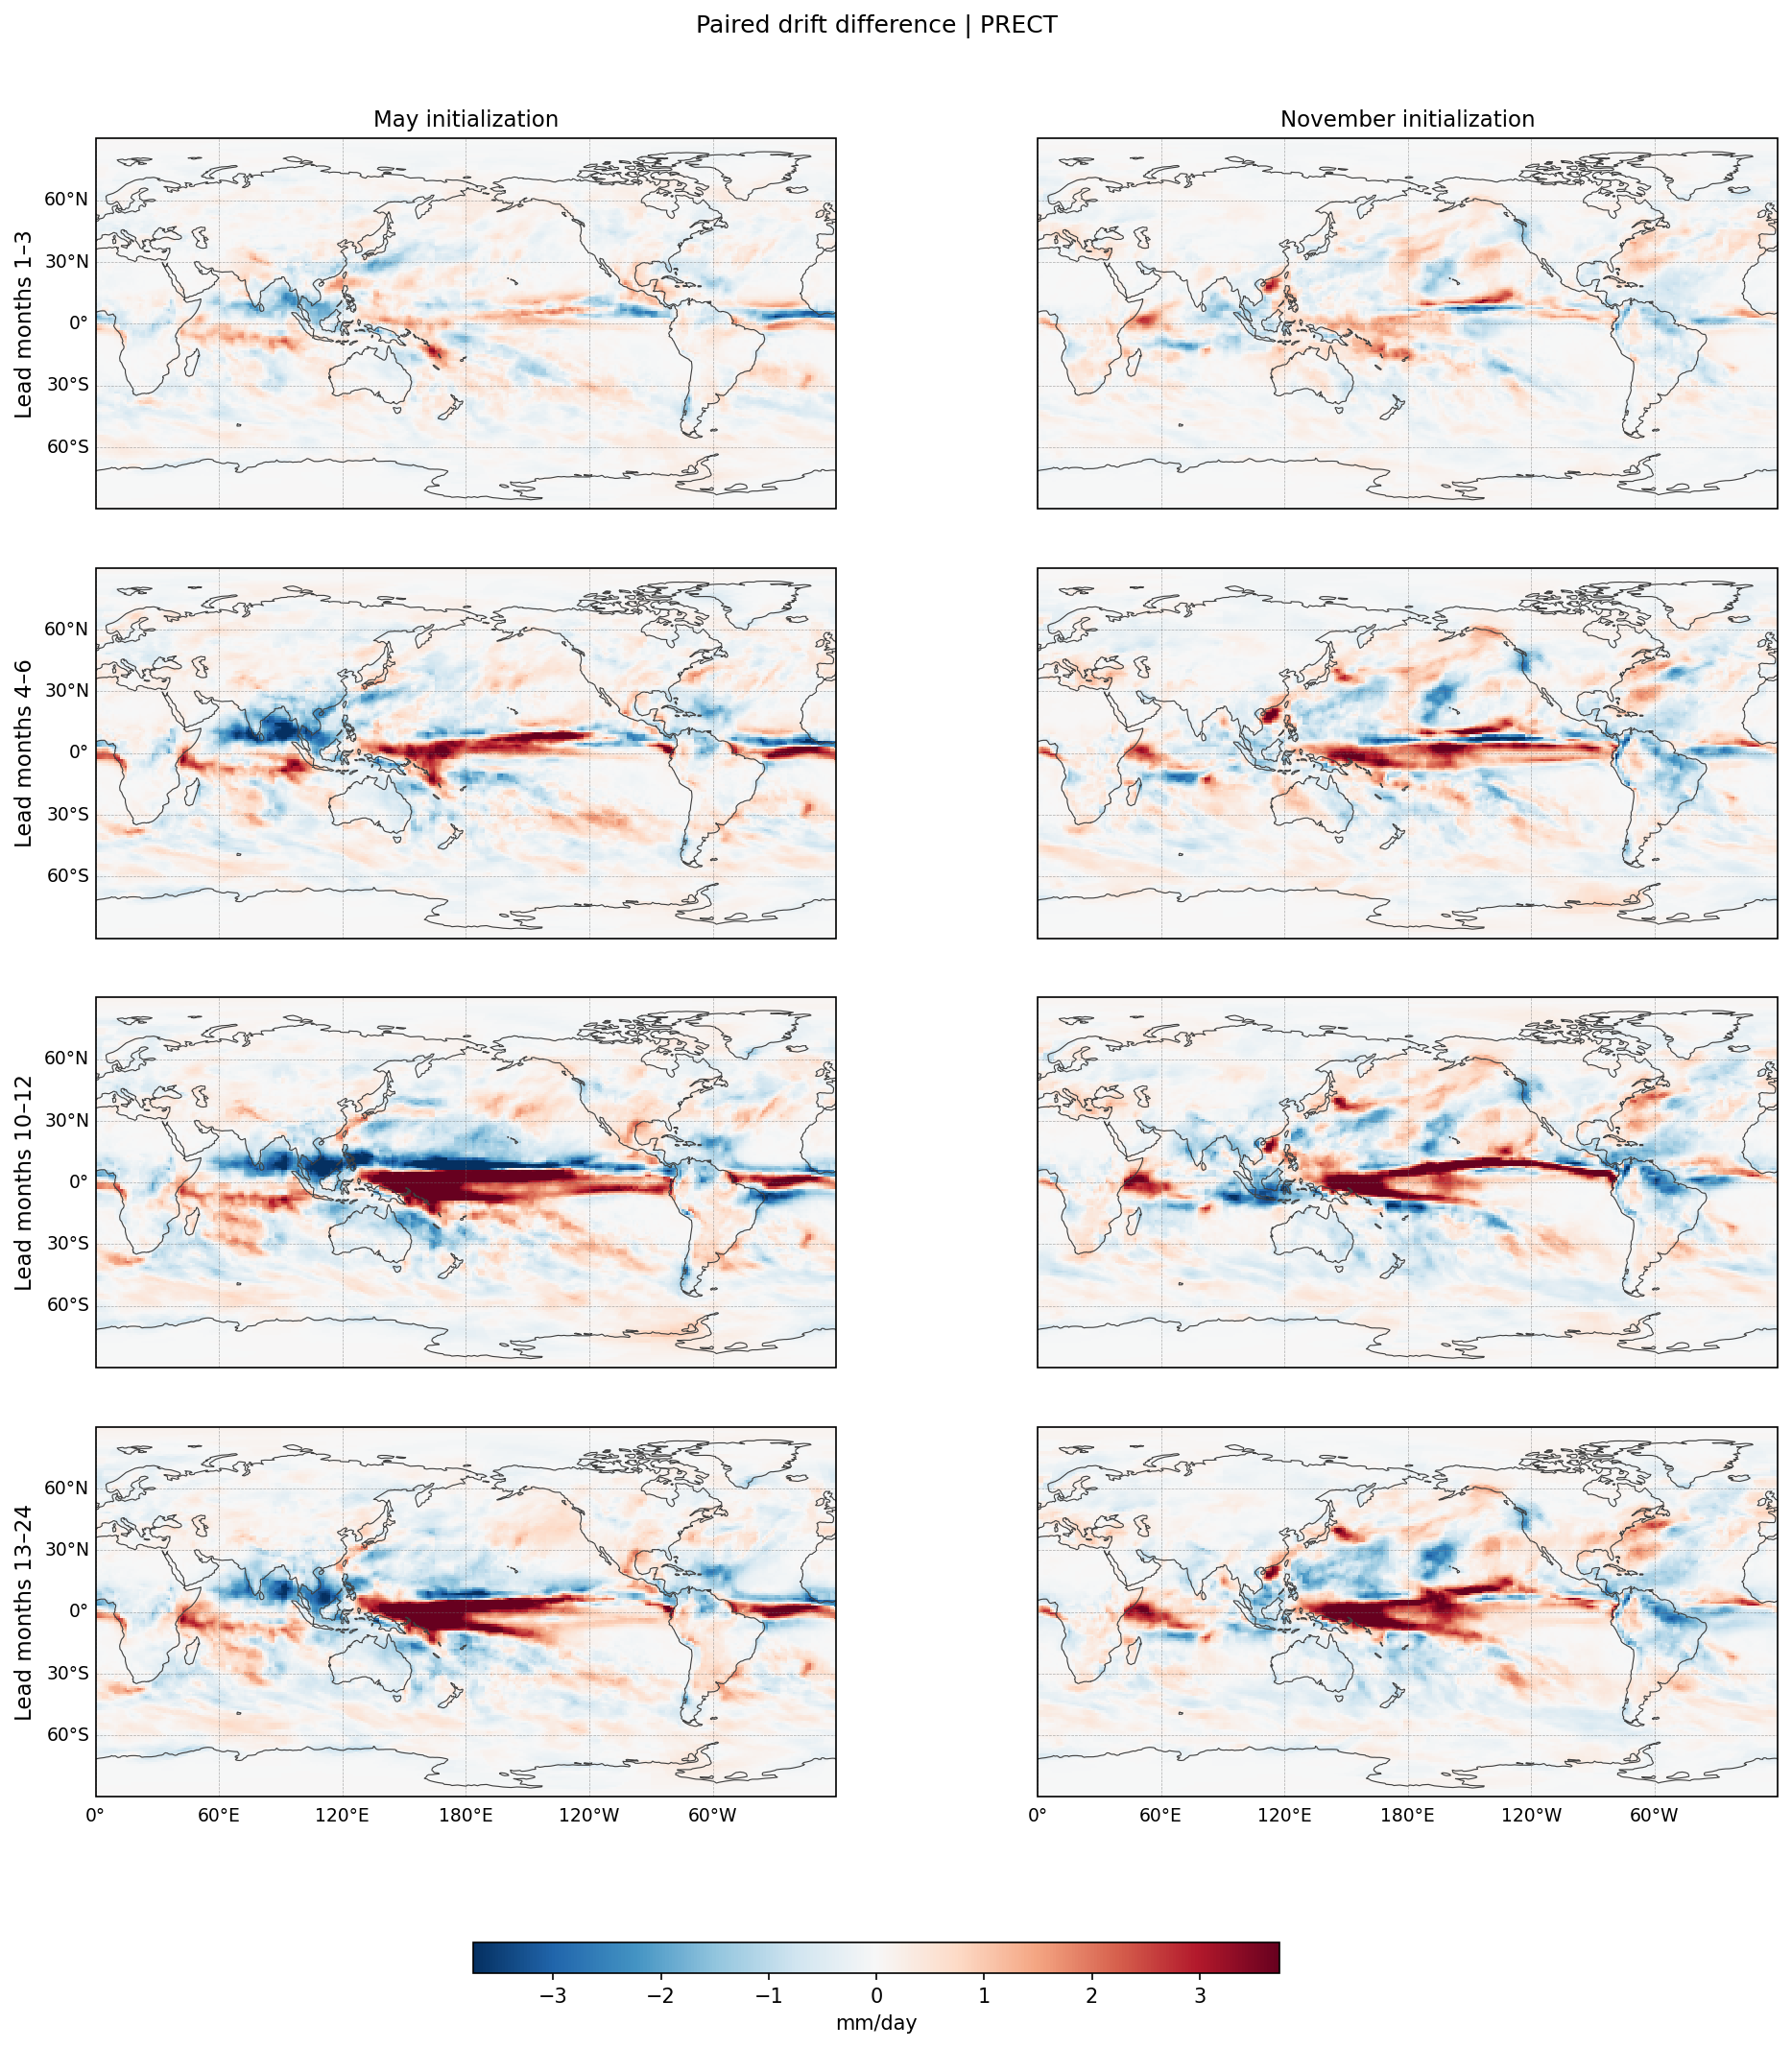

In [21]:
from IPython.display import Image, display as ipy_display

preview_path = FIGURE_OUTDIR / f'fig_{VARIABLE.lower()}_monthly_drift_paired_diff_grid_preview.png'
plotting_workflow.plot_paired_diff_grid(
    results=results,
    boot_results={},  # significance is added to the final Step 9 figure
    window_defs=config.window_defs,
    title=f'Paired drift difference | {VARIABLE}',
    outpath=preview_path,
    units=config.variables[0].plot_units,
)
ipy_display(Image(str(preview_path), width=1200))


## Step 8 — Bootstrap Confidence Intervals

Resamples paired init years with replacement.
May and November are bootstrapped separately.
Significance mask: True where 95% CI excludes zero.


In [22]:
%%time
if not STORE_VALID:
    boot_results = bootstrap_workflow.run_bootstrap(
        results=results, config=config, verbose=True,
    )
    save_diagnostic_store(STORE_PATH, results, boot_results, config=config,
                          variable=VARIABLE, workflow='monthly_drift', context=STORE_CONTEXT)
    print(f'Saved diagnostics: {STORE_PATH}')

for month, bm in boot_results.items():
    season_name = {5: 'May', 11: 'November'}.get(month, f'M{month:02d}')
    for win, bd in bm.items():
        sig = bd.get('significant')
        if sig is not None:
            frac = float(sig.mean(skipna=True))
            print(f'  {season_name:<12s} {win:<20s} frac_significant={frac:.2%}')


Step 8: Bootstrap — May
  months_1_3          n_years=3  frac_significant=27.89%
  months_4_6          n_years=3  frac_significant=28.25%
  months_10_12        n_years=3  frac_significant=37.28%
  second_year         n_years=3  frac_significant=36.18%
Step 8: Bootstrap — November
  months_1_3          n_years=3  frac_significant=22.62%
  months_4_6          n_years=3  frac_significant=24.95%
  months_10_12        n_years=3  frac_significant=31.40%
  second_year         n_years=3  frac_significant=32.62%
Saved diagnostics: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/atm/monthly_spatial/diagnostics/monthly_drift/PRECT/e54d69865626445e
  May          months_1_3           frac_significant=27.89%
  May          months_4_6           frac_significant=28.25%
  May          months_10_12         frac_significant=37.28%
  May          second_year          frac_significant=36.18%
  November     months_1_3           frac_significant=22.62%
  November     months_4_6           fra

## Step 9 — Generate Figures

Saves figures under `${ESP_LAB_FIGURE_OUTDIR}/leadtime_drift/atm/monthly_spatial/`:
- Adjustment maps (two-panel: ref vs test)
- One paired ΔD grid: lead windows by row, May/November by column, with significance stippling
- Zonal mean profiles
- Summary statistics table


In [23]:
%%time
summary_df = plotting_workflow.run_plotting(
    results=results,
    boot_results=boot_results,
    config=config,
    variable=VARIABLE,
    figure_outdir=FIGURE_OUTDIR,
    verbose=True,
)
display(summary_df)


Step 9: Figures — May  (PRECT)


/global/u2/z/zhan391/code/ESP-Lab/workflows/diagnostics/monthly_drift/plotting.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  May/months_1_3  → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial


/global/u2/z/zhan391/code/ESP-Lab/workflows/diagnostics/monthly_drift/plotting.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  May/months_4_6  → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial


...

  November/months_10_12  → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial


/global/u2/z/zhan391/code/ESP-Lab/workflows/diagnostics/monthly_drift/plotting.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  November/second_year  → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial

  Paired-difference grid → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial/fig_prect_monthly_drift_paired_diff_grid.png

  Summary table → /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/atm/monthly_spatial/summary_tables/prect_monthly_spatial_drift_summary.csv
variable   season       window  global_mean_dD  global_rmse_dD
   PRECT      May   months_1_3          0.0042          0.4452
   PRECT      May   months_4_6          0.0168          0.8050
   PRECT      May months_10_12          0.0509          1.3287
   PRECT      May  second_year          0.0531          1.0812
   PRECT November   months_1_3          0.0178          0.4408
   PRECT November   months_4_6          0.0346          0.7482
   PRECT November months_10_12          0.0371          0.9995
   PRECT November  second_year          0.0595          0.8838


,variable,season,window,global_mean_dD,global_rmse_dD
0,PRECT,May,months_1_3,0.0042,0.4452
1,PRECT,May,months_4_6,0.0168,0.8050
2,PRECT,May,months_10_12,0.0509,1.3287
3,PRECT,May,second_year,0.0531,1.0812
4,PRECT,November,months_1_3,0.0178,0.4408
5,PRECT,November,months_4_6,0.0346,0.7482
6,PRECT,November,months_10_12,0.0371,0.9995
7,PRECT,November,second_year,0.0595,0.8838


CPU times: user 1min 33s, sys: 9.19 s, total: 1min 43s
Wall time: 2min 32s


### Inline figure viewer

fig_prect_monthly_drift_paired_diff_grid.png


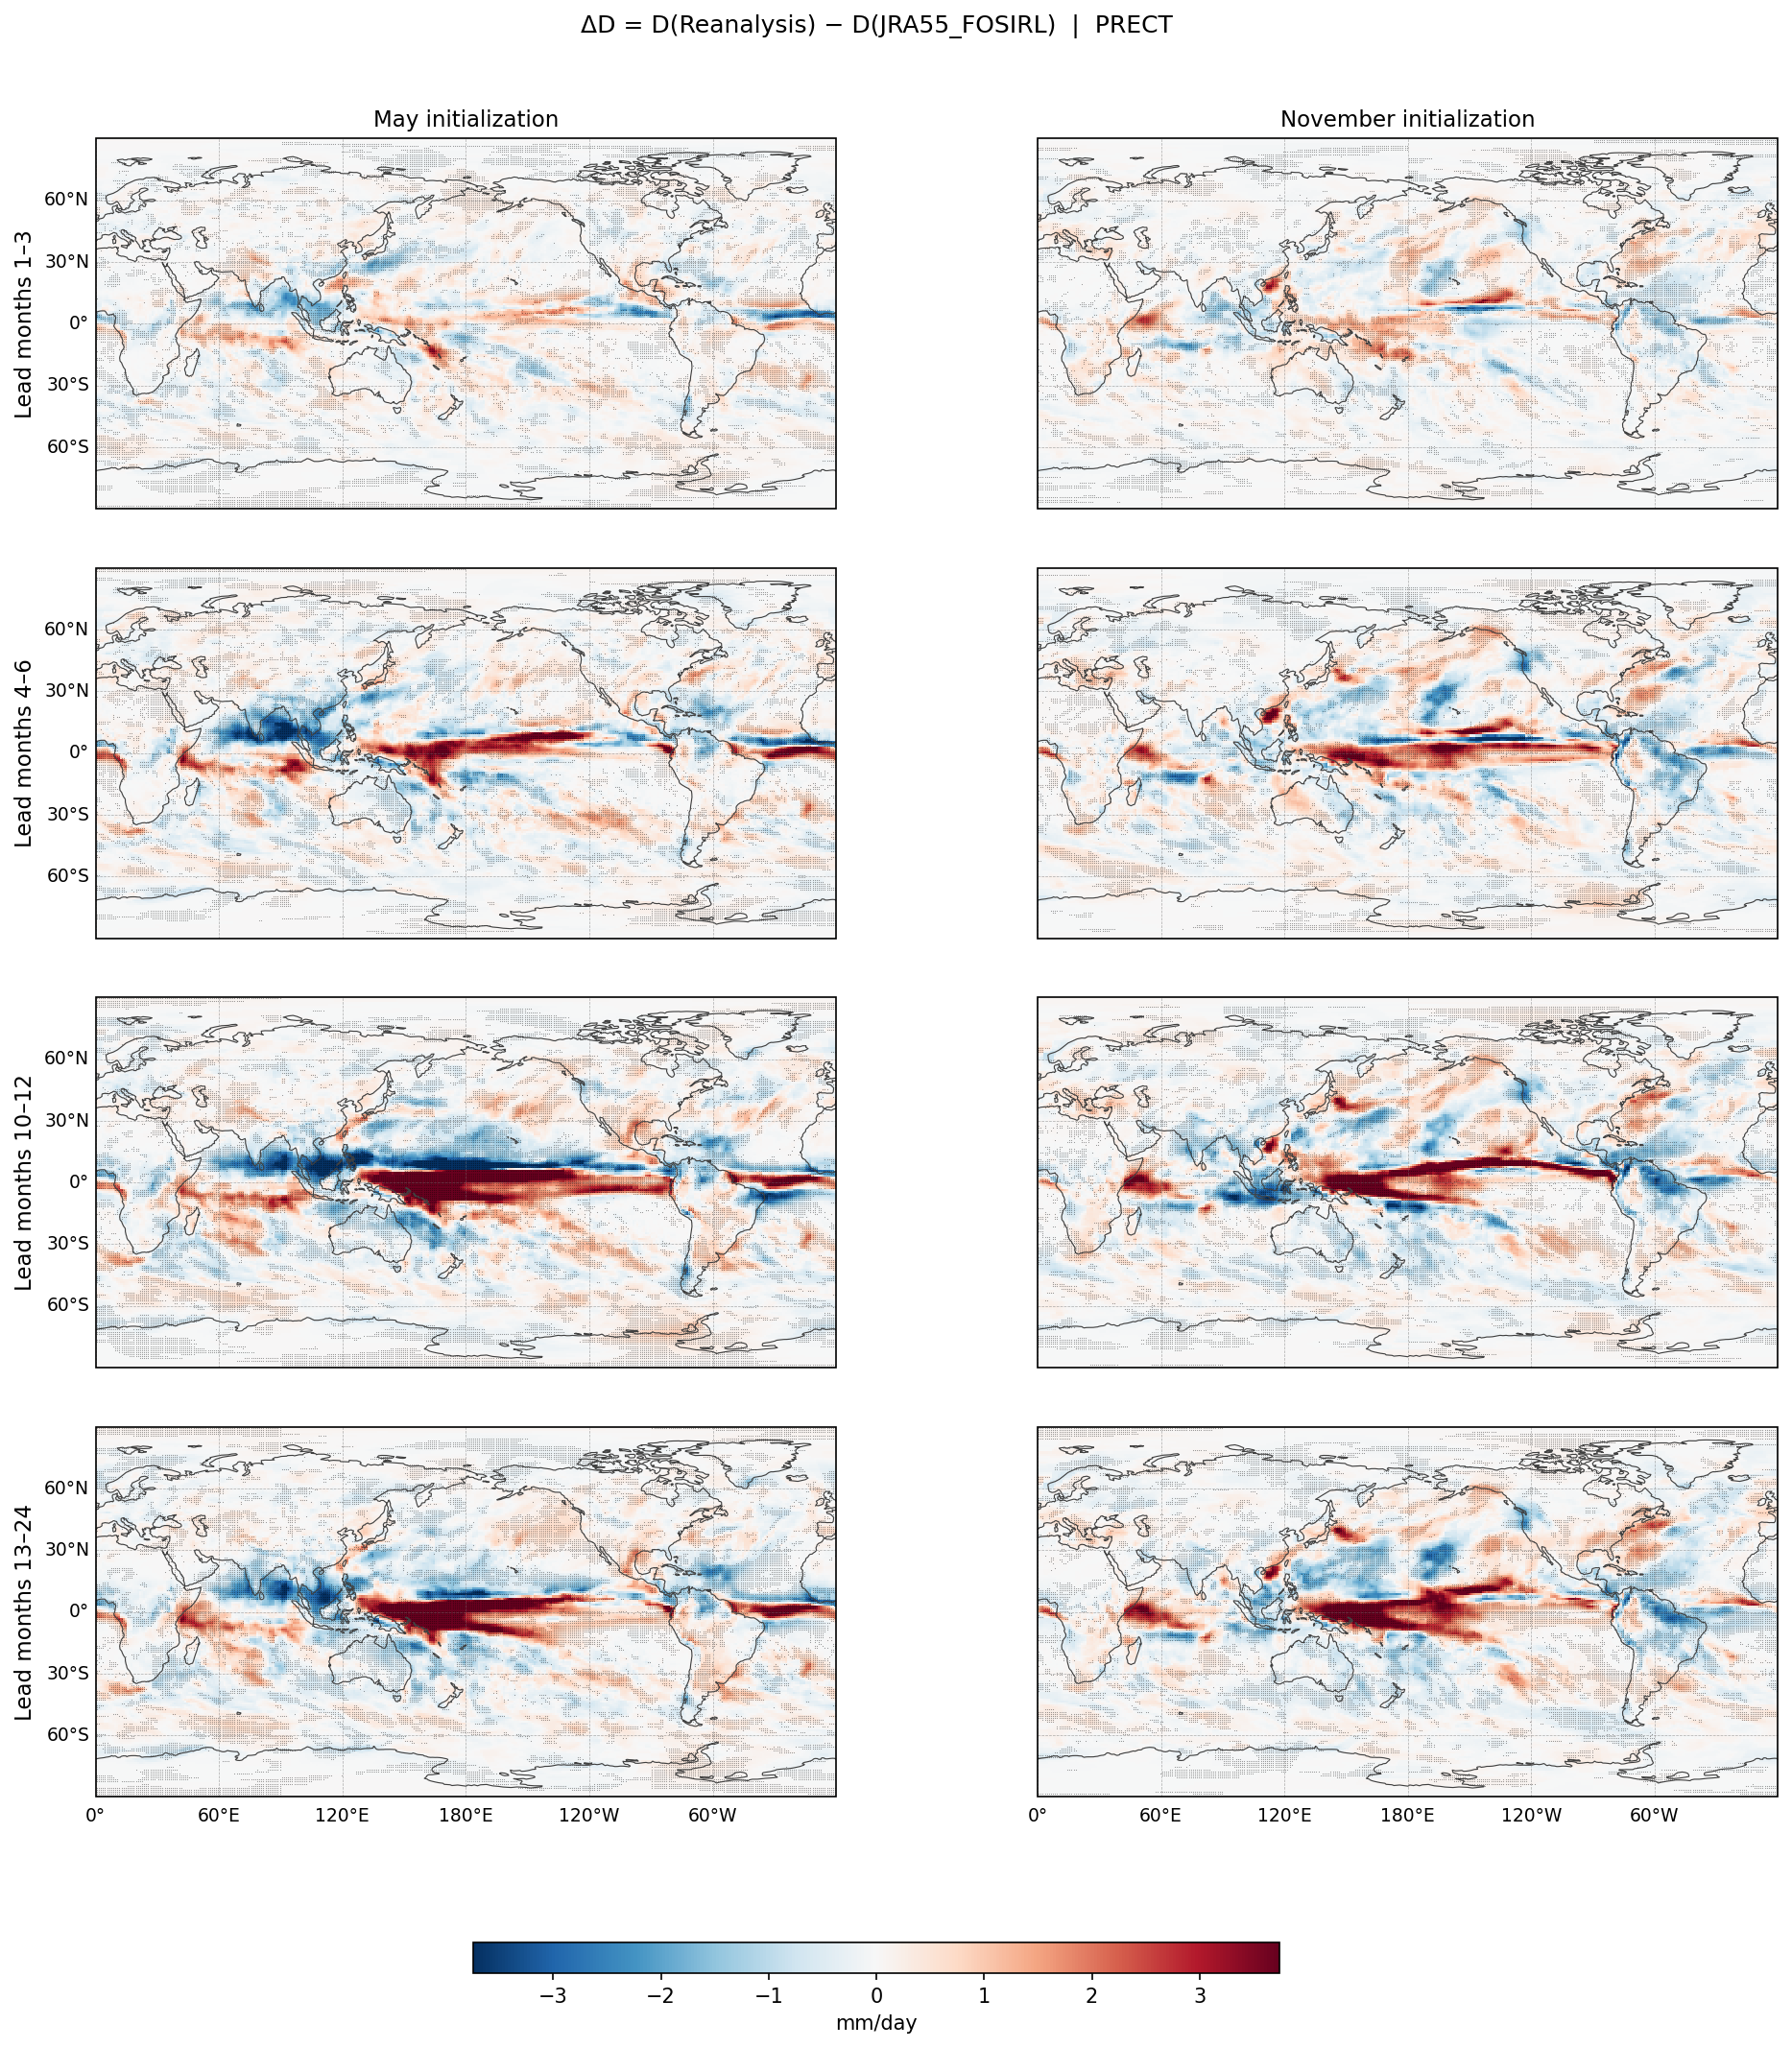

fig_prect_monthly_drift_paired_diff_grid_preview.png


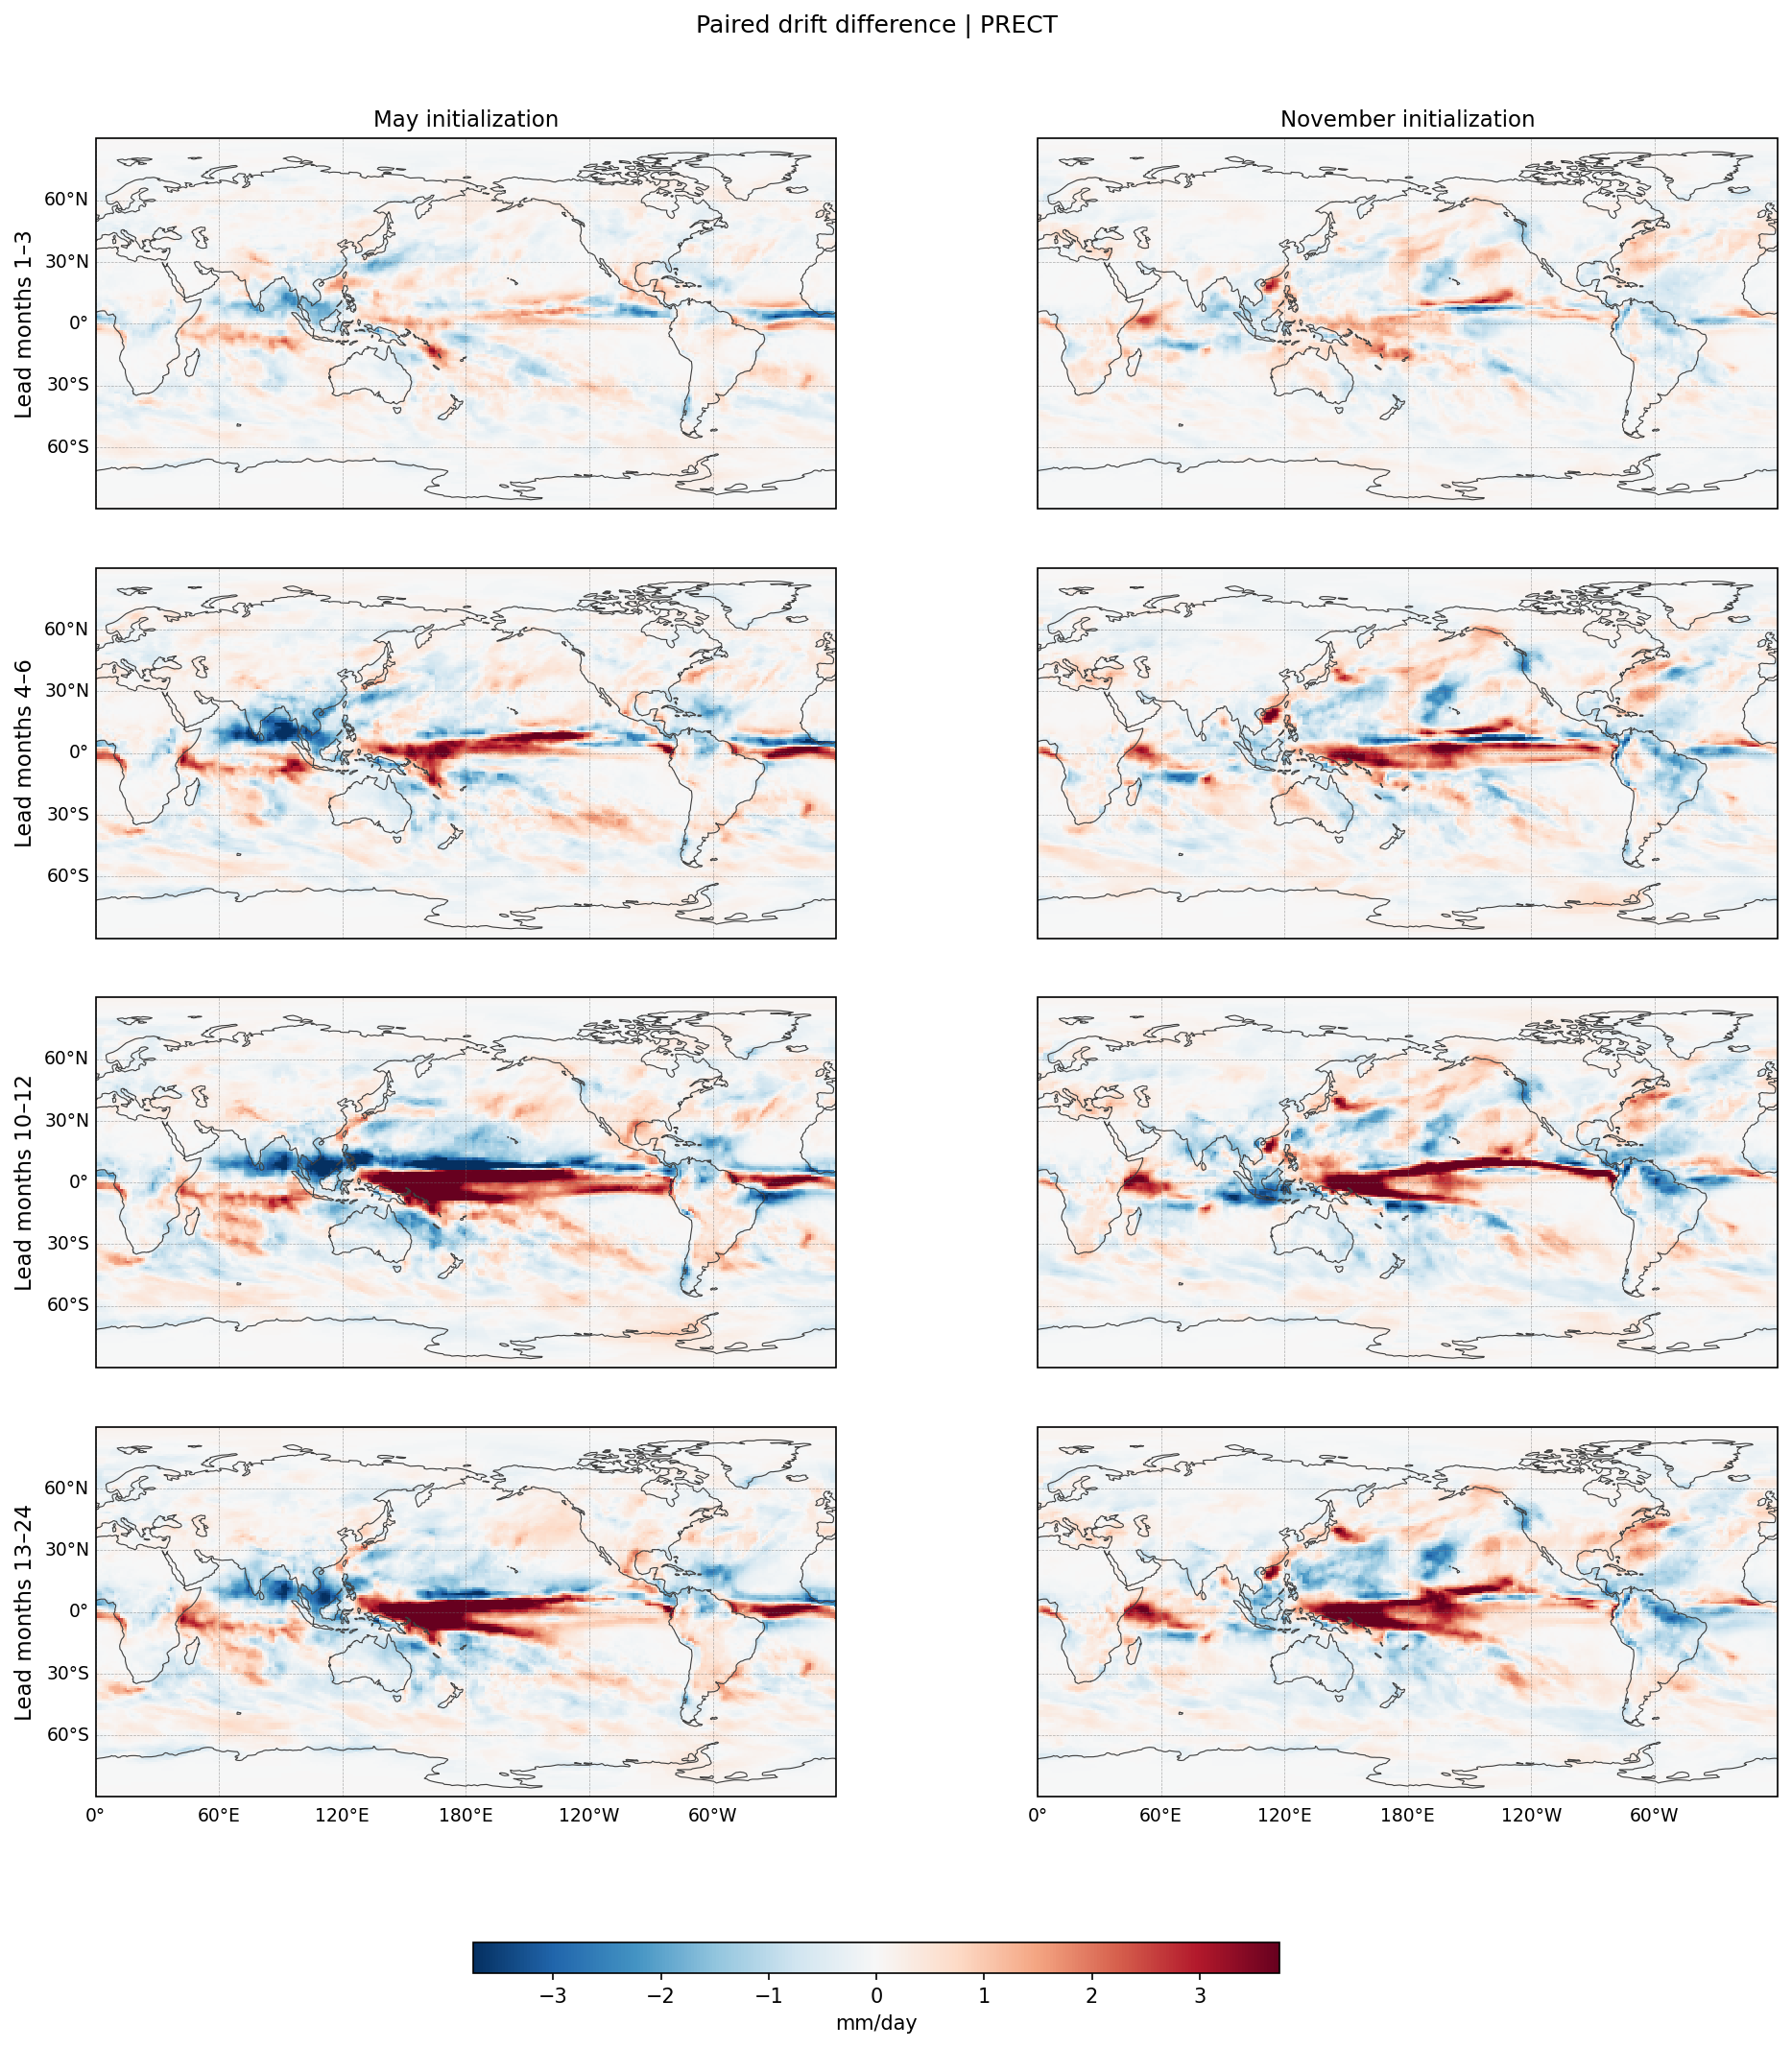

In [24]:
from IPython.display import Image, display as ipy_display
from pathlib import Path

fig_root = FIGURE_OUTDIR
all_figs = sorted(fig_root.rglob(f'fig_{VARIABLE.lower()}_monthly_drift_*paired_diff*.png'))
for p in all_figs[:6]:
    print(p.name)
    ipy_display(Image(str(p), width=800))


## Extend to additional variables

> Run the cells below after verifying PRECT looks physical.


In [25]:
# Uncomment to run TREFHT, LHFLX, SHFLX
for var in ['TREFHT', 'LHFLX', 'SHFLX']:
    config_v = configuration.build_monthly_config(
        pilot_only=PILOT_ONLY,
        pilot_years=PILOT_YEARS,
        pilot_months=PILOT_MONTHS,
        variable_filter=[var],
        output_root=OUTPUT_ROOT,
    )
    data_v, obs_v = preprocessing_workflow.run_preprocess(config_v, inventory_df, report, field=var)
    results_v     = diagnostics_workflow.run_diagnostics(data_v, config_v, obs_da=obs_v)
    boot_v        = bootstrap_workflow.run_bootstrap(results_v, config_v)
    plotting_workflow.run_plotting(
        results_v, boot_v, config_v, variable=var, figure_outdir=FIGURE_OUTDIR
    )


Step 5: Preprocess — TREFHT
  init_month=5  approved_years=[1980, 1981, 1982]
  init_month=11  approved_years=[1980, 1981, 1982]

  [JRA55_FOSIRL] init_month=5  years=[1980, 1981, 1982]


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' t

  Loaded JRA55_FOSIRL/1980050100  shape=(10, 24, 180, 360)


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/diagnostics/monthly_io.py:431: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' t

  Loaded JRA55_FOSIRL/1981050100  shape=(10, 24, 180, 360)


...

  November/months_4_6  → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial


/global/u2/z/zhan391/code/ESP-Lab/workflows/diagnostics/monthly_drift/plotting.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  November/months_10_12  → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial


/global/u2/z/zhan391/code/ESP-Lab/workflows/diagnostics/monthly_drift/plotting.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  November/second_year  → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial

  Paired-difference grid → /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/leadtime_drift/atm/monthly_spatial/fig_shflx_monthly_drift_paired_diff_grid.png

  Summary table → /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/atm/monthly_spatial/summary_tables/shflx_monthly_spatial_drift_summary.csv
variable   season       window  global_mean_dD  global_rmse_dD
   SHFLX      May   months_1_3         -0.0060          2.4916
   SHFLX      May   months_4_6         -0.0468          4.5298
   SHFLX      May months_10_12          0.0586          4.7734
   SHFLX      May  second_year          0.1065          4.3868
   SHFLX November   months_1_3          0.0503          2.5207
   SHFLX November   months_4_6         -0.0341          4.4531
   SHFLX November months_10_12          0.1317          5.0893
   SHFLX November  second_year          0.2317          4.7194


## Shutdown

In [26]:
close_cluster(cluster, client)
